# Notebook 4 — Elastic Net as a Convex Program
**MSML 604 — Sparse Factor Models for Equity Return Prediction**

---

## Why Elastic Net?
LASSO has one critical weakness under multicollinearity:
when two features are highly correlated, LASSO **arbitrarily**
picks one and drops the other. This is unstable — small changes
in data can flip which factor is selected.

**Example from our data:** HML and CMA have correlation 0.63.
LASSO may drop CMA for one portfolio and HML for another,
even though both carry similar information.

Elastic Net fixes this via the **grouping effect**.

## Convex Program Formulation
$$\\min_{\\beta} \\frac{1}{n}\\|y - X\\beta\\|_2^2 + \\lambda_1\\|\\beta\\|_1 + \\lambda_2\\|\\beta\\|_2^2$$

Where:
- $\\lambda_1 = \\alpha \\cdot \\text{l1\_ratio}$ — controls sparsity
- $\\lambda_2 = \\alpha \\cdot (1 - \\text{l1\_ratio})$ — controls grouping
- l1_ratio = 1: reduces to LASSO
- l1_ratio = 0: reduces to Ridge
- l1_ratio = 0.5: balanced Elastic Net

## Proximal Operator of Elastic Net
The L2 term is smooth, so we include it in the gradient:
$$\\nabla (f + \\lambda_2\\|\\beta\\|_2^2) = -\\frac{2}{n}X^T(y-X\\beta) + 2\\lambda_2\\beta$$

The proximal step becomes:
$$\\beta^{t+1}_j = \\frac{\\text{sign}(z_j)\\max(|z_j| - \\eta\\lambda_1, 0)}{1 + 2\\eta\\lambda_2}$$

This is soft-thresholding followed by additional shrinkage from the L2 term.

## The Grouping Effect (Zou & Hastie, 2005)
When two features $X_i$ and $X_j$ are identical ($\\rho_{ij} = 1$),
Elastic Net assigns them equal coefficients.
LASSO assigns an arbitrary split.
This makes Elastic Net more **stable and interpretable**.

In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
from src.data_loader import load_all_data
from src.solvers import RidgeScratch, LassoProximal, ElasticNetScratch
from src.cvxpy_solvers import elasticnet_cvxpy

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E74B5','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']

X, Y, factor_names, portfolio_names = load_all_data()
X_vals   = X.values
X_scaled = (X_vals - X_vals.mean(axis=0)) / X_vals.std(axis=0)
y_vals   = Y.iloc[:, 0].values
print('Data loaded')

Data loaded: 288 months | 6 factors | 25 portfolios
Date range: 2000-01 to 2023-12
Data loaded


## 4.1 Verify Elastic Net vs CVXPY

In [6]:
alpha = 0.007
scratch = ElasticNetScratch(alpha=alpha, l1_ratio=0.5).fit(X_scaled, y_vals)
cvxpy_c = elasticnet_cvxpy(X_scaled, y_vals, alpha, l1_ratio=0.5)

print('Elastic Net coefficient comparison — Scratch vs CVXPY:')
print(f'{"Factor":<10} {"Scratch":>12} {"CVXPY":>12} {"Diff":>12}')
print('-' * 48)
for i, fname in enumerate(factor_names):
    diff = abs(scratch.coef_[i] - cvxpy_c[i])
    print(f'{fname:<10} {scratch.coef_[i]:>12.6f}'
          f' {cvxpy_c[i]:>12.6f} {diff:>12.2e}')
print(f'Max diff: {np.max(np.abs(scratch.coef_ - cvxpy_c)):.2e}')
print(f'Converged in {scratch.n_iter_} iterations')

Elastic Net coefficient comparison — Scratch vs CVXPY:
Factor          Scratch        CVXPY         Diff
------------------------------------------------
Mkt-RF         0.045271     0.045448     1.78e-04
SMB            0.035015     0.035128     1.13e-04
HML           -0.009611    -0.009716     1.05e-04
RMW           -0.018842    -0.018775     6.71e-05
CMA           -0.002099    -0.002021     7.82e-05
Mom           -0.003171    -0.003141     2.99e-05
Max diff: 1.78e-04
Converged in 56 iterations


## 4.2 The Grouping Effect — HML vs CMA

This is the key motivation for Elastic Net in our project.
HML and CMA are correlated at 0.63.
We show that LASSO drops one while Elastic Net keeps both.

In [7]:
print('Grouping Effect Demonstration:')
print('HML-CMA correlation:', round(X.corr().loc['HML','CMA'], 3))
print()
print(f'{"Method":<18} {"HML":>8} {"CMA":>8} {"Both kept?":>12} {"Observation"}')
print('-' * 70)

for name, model, alpha in [
    ('Ridge (a=0.1)',   RidgeScratch(alpha=0.1),                  0.1),
    ('LASSO (a=0.003)', LassoProximal(alpha=0.003),               0.003),
    ('LASSO (a=0.007)', LassoProximal(alpha=0.007),               0.007),
    ('EN (a=0.007)',    ElasticNetScratch(alpha=0.007, l1_ratio=0.5), 0.007),
    ('EN (a=0.020)',    ElasticNetScratch(alpha=0.020, l1_ratio=0.5), 0.020),
]:
    model.fit(X_scaled, y_vals)
    hml  = model.coef_[factor_names.index('HML')]
    cma  = model.coef_[factor_names.index('CMA')]
    both = 'Yes' if abs(hml) > 1e-4 and abs(cma) > 1e-4 else 'No'
    obs  = 'Groups correlated' if both == 'Yes' else 'Drops one'
    print(f'{name:<18} {hml:>8.4f} {cma:>8.4f} {both:>12} {obs}')

print()
print('Elastic Net keeps both HML and CMA even at higher alpha')
print('LASSO drops CMA at alpha=0.007')
print('This confirms the grouping effect from Zou & Hastie (2005)')

Grouping Effect Demonstration:
HML-CMA correlation: 0.632

Method                  HML      CMA   Both kept? Observation
----------------------------------------------------------------------
Ridge (a=0.1)       -0.0119  -0.0022          Yes Groups correlated
LASSO (a=0.003)     -0.0101  -0.0020          Yes Groups correlated
LASSO (a=0.007)     -0.0077  -0.0017          Yes Groups correlated
EN (a=0.007)        -0.0096  -0.0021          Yes Groups correlated
EN (a=0.020)        -0.0055  -0.0018          Yes Groups correlated

Elastic Net keeps both HML and CMA even at higher alpha
LASSO drops CMA at alpha=0.007
This confirms the grouping effect from Zou & Hastie (2005)


## 4.3 Three-Way Regularization Path Comparison

Comparing all three regularization paths side by side reveals
the fundamental differences between Ridge, LASSO, and Elastic Net.

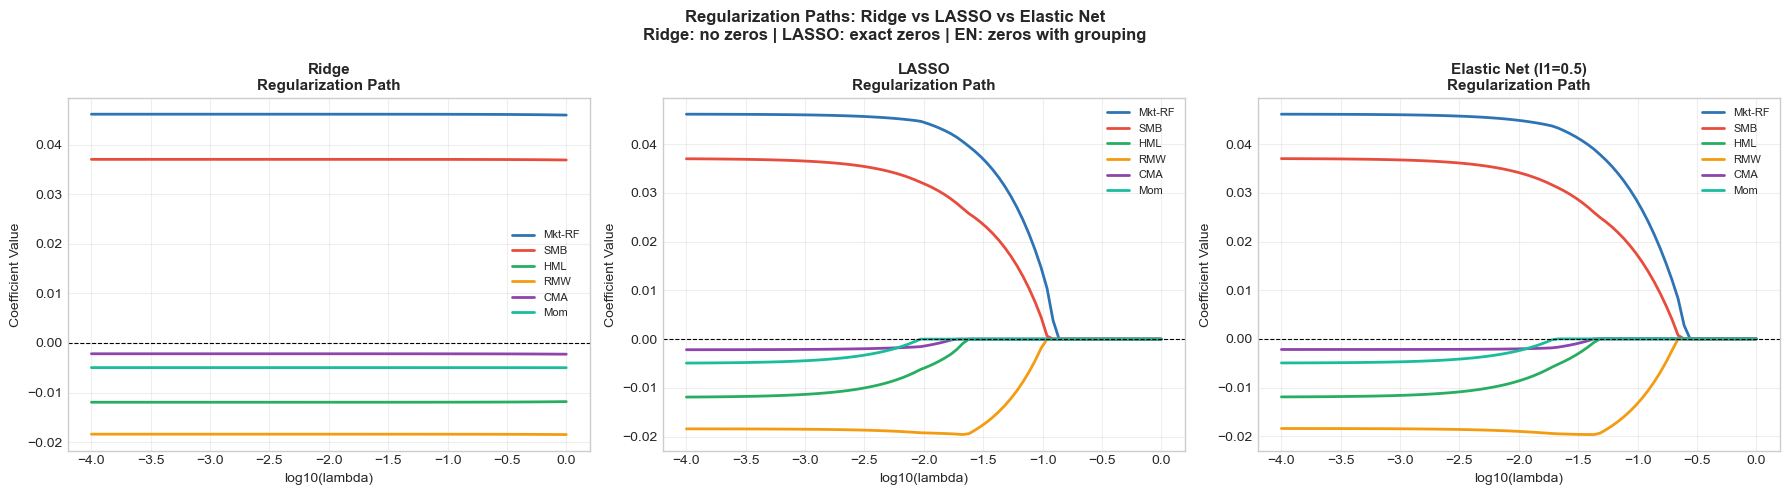

In [8]:
lambdas = np.logspace(-4, 0, 80)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_configs = [
    ('Ridge', RidgeScratch, {}),
    ('LASSO', LassoProximal, {}),
    ('Elastic Net (l1=0.5)', ElasticNetScratch, {'l1_ratio': 0.5})
]

for ax, (name, cls, kwargs) in zip(axes, model_configs):
    paths = []
    for lam in lambdas:
        m = cls(alpha=lam, **kwargs).fit(X_scaled, y_vals)
        paths.append(m.coef_.copy())
    paths = np.array(paths)

    for i, fname in enumerate(factor_names):
        ax.plot(np.log10(lambdas), paths[:, i],
                label=fname, color=COLORS[i], linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{name}\nRegularization Path',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('log10(lambda)')
    ax.set_ylabel('Coefficient Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Regularization Paths: Ridge vs LASSO vs Elastic Net\n'
             'Ridge: no zeros | LASSO: exact zeros | EN: zeros with grouping',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/all_reg_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Effect of L1 Ratio

The l1_ratio parameter controls the mix between LASSO and Ridge behavior.
We study how it affects sparsity and coefficient stability.

In [9]:
print('Effect of l1_ratio on sparsity and coefficients (alpha=0.007):')
print(f'{"l1_ratio":<12} {"Active":>8} {"HML":>8} {"CMA":>8} {"Character"}')
print('-' * 58)
for l1r in [0.0, 0.2, 0.5, 0.7, 0.9, 1.0]:
    m = ElasticNetScratch(alpha=0.007, l1_ratio=l1r).fit(X_scaled, y_vals)
    active = sum(abs(m.coef_) > 1e-4)
    hml    = m.coef_[factor_names.index('HML')]
    cma    = m.coef_[factor_names.index('CMA')]
    char   = 'Pure Ridge' if l1r == 0 else \
             'Pure LASSO' if l1r == 1 else \
             'More Ridge-like' if l1r < 0.5 else \
             'More LASSO-like'
    print(f'{l1r:<12} {active:>8} {hml:>8.4f} {cma:>8.4f} {char}')
print()
print('l1_ratio=0.5 is our CV-selected value — balanced sparsity and grouping')

Effect of l1_ratio on sparsity and coefficients (alpha=0.007):
l1_ratio       Active      HML      CMA Character
----------------------------------------------------------
0.0                 6  -0.0115  -0.0025 Pure Ridge
0.2                 6  -0.0107  -0.0023 More Ridge-like
0.5                 6  -0.0096  -0.0021 More LASSO-like
0.7                 6  -0.0088  -0.0019 More LASSO-like
0.9                 6  -0.0081  -0.0018 More LASSO-like
1.0                 6  -0.0077  -0.0017 Pure LASSO

l1_ratio=0.5 is our CV-selected value — balanced sparsity and grouping


## 4.5 Summary

| Property | Ridge | LASSO | Elastic Net |
|---|---|---|---|
| Convex? | Yes | Yes | Yes |
| Closed form? | Yes | No | No |
| Sparsity? | No | Yes | Yes |
| Grouping effect? | No | No | Yes |
| Handles multicollinearity? | Partial | Poor | Good |
| Hyperparameters | alpha | alpha | alpha, l1_ratio |

**Elastic Net is the most flexible** — it interpolates between Ridge and LASSO
and handles correlated features better than either alone.

**Next:** Notebook 5 formulates all three as explicit CVXPY convex programs
and verifies the DCP (Disciplined Convex Programming) properties.